In [2]:


import json

with open("../data/results_20250815.json", "r") as f:
    results = json.load(f)


successful = []
failed = []
 
for result in results:
    if result['metadata']['num_chunks_used'] >= 1:
        successful.append(result)
    else:
        failed.append(result)

print(len(successful))
print(len(failed))



14
3


In [ ]:


retrieval_accuracy = []

for result in successful:
    retrieval_number = 0 
    
    expected_chunks = []
    for chunk in result['expected_chunks']:
        if type(chunk['chunk_id']) == list:
            expected_chunks.extend(chunk['chunk_id'])
        else:
            expected_chunks.append(chunk['chunk_id'])



    for chunk in result['chunks']:
        if chunk in expected_chunks:
            retrieval_number += 1
            
    retrieval_accuracy.append(retrieval_number / len(expected_chunks))
    
print(sum(retrieval_accuracy) / len(retrieval_accuracy))



0.8996598639455782


In [21]:
from decompose_string_tool import decompose_string 




retrieval_accuracy = []

for result in successful:
    retrieval_number = 0 
    
    expected_chunks = []
    for chunk in result['expected_chunks']:
        if type(chunk['chunk_id']) == list:
            expected_chunks.extend(chunk['chunk_id'])
        else:
            expected_chunks.append(chunk['chunk_id'])

    chunk_analysis = decompose_string(result['xyz_answer']) 
    chunk_used_index = []
    for chunk_a in chunk_analysis:
        chunk_index = chunk_a['references']
        if chunk_index not in chunk_used_index:
            for number in chunk_index:
                chunk_used_index.append(number-1)
    chunk_used_id = [result['chunks'][index] for index in chunk_used_index]
    # print(chunk_used_id)
    # print(expected_chunks)
    for chunk in expected_chunks:
        if chunk in chunk_used_id:
            retrieval_number += 1
            break
            
    retrieval_accuracy.append(retrieval_number / len(expected_chunks))
    
print(retrieval_accuracy)

print(sum(retrieval_accuracy) / len(retrieval_accuracy))


[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.3333333333333333, 0.3333333333333333, 0.5, 0.2, 0.5, 0.14285714285714285, 0.0, 0.5]
0.6078231292517007


In [1]:
from deep_eval import DeepEval
from decompose_string_tool import decompose_string 
import json

all_data = {}
with open("../experiments_docs_processed/baoxian.json", "r") as f:
    chunks = json.load(f) 
    chunks = chunks['chunks']
    chunks = {chunk['chunk_id']: chunk for chunk in chunks}

with open("../data/results_20250826.json", "r") as f:
    results = json.load(f)
        
            


In [3]:
all_evaluated = []
questions =[
        "What is the Important Notice and Disclaimer Concerning the United States Patient Protection and Affordable Care Act (PPACA) for these insurance plans, and what implications does it have for U.S. citizens or residents?",
        "How are pre-existing conditions generally handled across the Atlas Travel, Atlas, StudentSecure, and GeoBlue Navigator plans, and what are the specific conditions that qualify for coverage under the 'Acute Onset of Pre-existing Conditions' benefit?",
        "What are the eligibility requirements for members applying for coverage under the Atlas Travel, StudentSecure, GeoBlue Navigator, and Patriot Exchange plans, including any age or visa-related criteria?",
        "What are the rules and associated fees for cancelling a policy and receiving a refund for Atlas Travel, StudentSecure, and Patriot Exchange plans?",
        "How do the Atlas Travel, StudentSecure, and Patriot Exchange plans utilize a U.S. Preferred Provider Organization (PPO) network for medical treatment within the United States, and what are the benefits of using PPO providers?",
        "Outline the steps and submission timelines required to file a claim for medical expenses under the Atlas Travel, Atlas, StudentSecure, and Patriot Exchange plans.",
        "Describe the Appeals and Complaints Procedure available to policyholders of Atlas Travel, StudentSecure, and GeoBlue Navigator if a claim is denied or if they wish to make a complaint.",
        "Explain the Arbitration and Class Action Waiver clause in the Atlas Travel and StudentSecure policies, including the types of disputes it covers, the arbitration process, and how a member can opt out.",
        "What are the overall maximum limits for medical expenses in the various Atlas Travel, Atlas, and StudentSecure plans, and how do these limits vary based on the insured person's age or the specific plan type?",
        "Detail the emergency room co-payment requirements for claims incurred both in the U.S. and outside the U.S. under the Atlas Travel, Atlas, and StudentSecure plans.",
        "What specific sports and activities are generally excluded from coverage across the Atlas Travel, StudentSecure, and Patriot Exchange plans, and are there any optional riders available for additional coverage for certain activities?",
        "What are the conditions and limitations for eligible medical expenses resulting from an Act of Terrorism under Atlas Travel, StudentSecure, and Patriot Exchange, including geographic restrictions and types of agents used?",
        "How is mental health disorder treatment covered under the StudentSecure plans (Elite, Select, Budget, Smart), what are the limits on visits or inpatient days, and what are the specific exclusions for mental health services across StudentSecure and GeoBlue Navigator?",
        "Compare the maternity care coverage, including complications of pregnancy and newborn care, as described in the StudentSecure and GeoBlue Navigator plans, and highlight any differences or exclusions, particularly with the Patriot Exchange plan.",
        "Under the Patriot Exchange plan, which services require pre-certification, and what are the financial consequences (e.g., reduction of eligible medical expenses, maximum penalties) if these pre-certification requirements are not met?",
        "Provide the definition of 'Pre-existing Condition' as found in the Atlas Travel, Atlas, StudentSecure, and GeoBlue Navigator documents, noting any variations in the look-back periods.",
        "What are the rules regarding eligibility for coverage within or outside of the home country for U.S. citizens and non-U.S. citizens under the Atlas Travel and StudentSecure plans, including restrictions on establishing a new home country?",
        "How do deductibles and coinsurance maximums cross-accumulate or apply across U.S. Participating Provider, U.S. Non-Participating Provider, and International locations within the GeoBlue Navigator plan?",
        "Describe the benefits and exclusions for Accidental Death & Dismemberment under the Atlas Travel, StudentSecure, and GeoBlue Navigator plans, including any age-based limits or specific causes of loss that are not covered.",
        "What coverage is offered for natural disasters, specifically for replacement accommodations and evacuation, under the Atlas Travel plan, including any optional riders like the Optional Crisis Response Benefit Rider?"
    ]

for result, question in zip(results, questions):
    input_question = question
    
    input_chunks = result['chunks']
    
    chunk_analysis = decompose_string(result['xyz_answer']) 

    for information in chunk_analysis:
        content = information['content']
        references = information['references']
        try:
            chunk_ids_local = [input_chunks[index-1] for index in references]
            chunk_information = [chunks[chunk_id] for chunk_id in chunk_ids_local]
        except:
            print(f"References: {references}")
            print(f"Input Chunks number: {len(input_chunks)}")
            continue
        
        all_reference_text = []
        for index, chunk in enumerate(chunk_information):
            local_reference_text = ""
            local_reference_text += f"Summary: {chunk.get('summary', '')}\n"
            local_reference_text += f"Insights: {chunk.get('insights', '')}\n"
            local_reference_text += f"OriginalContent: {chunk.get('chunk_markdown_content', '')}\n\n"
            all_reference_text.append(local_reference_text)
        
        all_evaluated.append({
            "question": input_question,
            "content": content,
            "retrieval_context": all_reference_text,
        })
        
        # eval=DeepEval(  # 创建测试用例
        #     question=input_question, 
        #     actual_output=content,
        #     retrieval_context=all_reference_text,
        #     # expected_output=result['xyz_answer']
        # )
        # result = eval.faithfulness()
        
        # print("--------------------------------")
        # print(f"question: {input_question}")
        # print(f"content: {content}")
        # print(f"retrieval_context: {all_reference_text}")
        # print(f"faithfulness: {result}")
        
        
        

In [4]:
import json

with open("../data/metric_0827.json", "w") as f:
    json.dump(all_evaluated, f, indent=4)

In [2]:
from deepeval.metrics import AnswerRelevancyMetric, FaithfulnessMetric, ContextualRelevancyMetric, ContextualPrecisionMetric, ContextualRecallMetric  # 导入评估器  

from deepeval.test_case import LLMTestCase  # 导入测试用例 
metric= FaithfulnessMetric(  # 创建忠实度评估器
    threshold=0.7,
    model="gpt-4.1",
    include_reason=True,
    # verbose_mode=True
)
test_case = LLMTestCase(  # 创建测试用例
    input="Does the success of chain-of-thought prompting depend on a particular linguistic style?",
    retrieval_context=["Summary: This chunk examines the robustness of chain-of-thought prompting in language models, specifically its sensitivity to differences in annotators, linguistic styles, prompt exemplars, and prompt ordering. Through experiments with LaMDA 137B on GSM8K and MAWPS, and using prompts crafted by multiple annotators and randomly sampled from the GSM8K dataset, the study finds that, while some variance exists, all chain-of-thought prompt sets substantially outperform standard prompting. Robustness extends to exemplar source, order, and quantity, suggesting that chain-of-thought gains do not hinge on prompt idiosyncrasies.\nInsights: ['Chain-of-thought prompting for arithmetic reasoning remains robust despite significant variance in prompt linguistic style, as shown with different annotators.', 'All tested chain-of-thought prompts, regardless of annotator, outperform standard prompting by a large margin in LaMDA 137B experiments on GSM8K and MAWPS benchmarks.', 'Prompting with chains of thought written by independent annotators (not co-authors) also leads to substantial gains, indicating method robustness to writer background.', 'Concise chains of thought, inspired by other solution styles, are similarly effective, showing flexibility in prompt elaboration.', 'Randomly sampled exemplars from GSM8K, which already include reasoning steps, are as effective as carefully written ones, affirming robustness to exemplar source.', 'Chain-of-thought prompting performance is not overly sensitive to the specific examples used in the few-shot prompt, expanding applicability.', 'The robustness of chain-of-thought prompting extends to variations in exemplar order and the number of exemplars, as evidenced by reference to Appendix A.2.', 'Variation in performance across different prompts is expected for exemplar-based prompting, but does not undermine the consistent gains over standard methods.', 'The effective use of chain-of-thought prompting does not require tuning for linguistic style or strict adherence to a solution template.', 'The success of chain-of-thought prompting holds across both manually composed and dataset-derived exemplars.', 'Robustness findings hold for arithmetic reasoning tasks; similar results in other reasoning domains may require further confirmation.', 'Experimental results support that chain-of-thought prompting is not fragile to prompt formulation or author but is a generally dependable improvement technique.']\nOriginalContent: 3.4 Robustness of Chain of Thought\nSensitivity to exemplars is a key consideration of prompting approaches—for instance, varying the permutation of few-shot exemplars can cause the accuracy of GPT-3 on SST-2 to range from near chance $(54.3\\%)$ to near state of the art $(93.4\\%)$ (Zhao et al., 2021). In this final subsection, we evaluate robustness to chains of thought written by different annotators. In addition to the results above, which used chains of thought written by an Annotator A, two other co-authors of this paper (Annotators B and C) independently wrote chains of thought for the same few-shot exemplars (shown in Appendix H). Annotator A also wrote another chain of thought that was more concise than the original, following the style of solutions given in Cobbe et al. (2021).1  \nFigure 6 shows these results for LaMDA 137B on GSM8K and MAWPS (ablation results for other datasets are given in Appendix Table 6 / Table 7). Although there is variance among different chain of thought annotations, as would be expected when using exemplar-based prompting (Le Scao and Rush, 2021; Reynolds and McDonell, 2021; Zhao et al., 2021), all sets of chain of thought prompts outperform the standard baseline by a large margin. This result implies that successful use of chain of thought does not depend on a particular linguistic style.  \n![](https://netmind-public-files.s3.us-west-2.amazonaws.com/8bdbfba71f2f46189f05ddd62ebe2b76/7ec08f4391c9c20cbd82c880587e0ee7cc74ee04caecf44662ef2535468cc7fb.jpg)\nFigure 6: Chain-of-thought prompting has variance for different prompt examples (as expected) but outperforms standard prompting for various annotators as well as for different exemplars.  \nTo confirm that successful chain-of-thought prompting\nworks for other sets of exemplars, we also run experiments\nwith three sets of eight exemplars randomly sampled from the GSM8K training set, an independent  \nsource (examples in this dataset already included reasoning steps like a chain of thought).2 Figure 6 shows that these prompts performed comparably with our manually written exemplars, also substantially outperforming standard prompting.  \nIn addition to robustness to annotators, independently-written chains of thought, different exemplars, and various language models, we also find that chain-of-thought prompting for arithmetic reasoning is robust to different exemplar orders and varying numbers of exemplars (see Appendix A.2).\n\n"],
    actual_output=""" 
Chain-of-thought (CoT) prompting does **not** depend on a particular linguistic style to be effective. Instead, it is robust across different annotators, writing styles, and prompt variations, though careful prompt engineering can still influence performance in some tasks.

---

## Main Findings

### 1. Robustness to Linguistic Style and Annotator Variation

- Chain-of-thought prompting consistently outperforms standard prompting across a wide range of tasks, regardless of the linguistic style or background of the annotator who writes the reasoning steps.    
"""
)
metric.measure(test_case)  # 评估忠实度
print(metric.score)  # 存储忠实度得分

Output()

0.75


In [4]:
metric.reason

'The score is 0.75 because the actual output overgeneralizes the evidence, claiming chain-of-thought prompting outperforms standard prompting across a wide range of tasks, while the retrieval context only supports this for arithmetic reasoning tasks.'

In [12]:
len(all_evaluated)

289

In [4]:
import json 

with open("metric_0815_faithfulness_result.json", "r") as f:
    data = json.load(f)

print(data[0].keys())
print(data[0]["faithfulness"])

dict_keys(['question', 'content', 'retrieval_context', 'faithfulness'])
{'score': 1.0, 'reason': 'Great job! There are no contradictions, so the actual output is fully faithful to the retrieval context.'}


In [10]:
scores= 0
for score in not_sure_result:
    scores += score ["faithfulness"]['score']

In [12]:
274/(269+13)

0.9716312056737588

In [6]:
fail_result = []
good_result = [] 
not_sure_result = []


for faithfulness_data in data: 
    
    if not faithfulness_data["retrieval_context"]:
        fail_result.append(faithfulness_data)
    elif faithfulness_data["faithfulness"]['score'] != 1:
        not_sure_result.append(faithfulness_data)
    else:
        good_result.append(faithfulness_data['faithfulness']['score'])

print(len(fail_result), len(good_result), len(not_sure_result))
    

7 269 13


In [8]:
for not_sure_data in not_sure_result:
    # print(not_sure_data["retrieval_context"])
    print(not_sure_data["faithfulness"])
    # print(not_sure_data["reason"])
    print("-"*100)

{'score': 0.5, 'reason': "The score is 0.50 because the actual output incorrectly claims that the Wikipedia search tool provides up-to-date or detailed content, while the retrieval context only mentions that it returns short text snippets relevant to a search term and does not state anything about supplementing the model's knowledge with up-to-date content."}
----------------------------------------------------------------------------------------------------
{'score': 0.6666666666666666, 'reason': 'The score is 0.67 because the actual output incorrectly claims that QLORA matches full 16-bit finetuning performance at 33B and 65B scales, while the retrieval context clarifies that this equivalence was not established due to resource constraints.'}
----------------------------------------------------------------------------------------------------
{'score': 0.5, 'reason': 'The score is 0.50 because the actual output incorrectly claims that GLUE and Super-NaturalInstructions were main bench

In [15]:
import json 

with open("notebooklm_examples_new_faithfulness.jsonl", "r") as f:
    data = json.load(f)




In [19]:
all_score = 0 
number = 0 

for question in data:
    for chunk in question["chunks"]:
        all_score += chunk["faithfulness"]['score']
        number += 1 

print(all_score/number)

0.9652317880794702


In [ ]:
0.9652317880794702

In [20]:
with open("notebooklm_examples_new_faithfulness.json", "w") as f:
    json.dump(data, f, indent=4)

In [22]:
import json 

with open('metric_0815_test_relevence.json', 'r') as f:
    xyz_rag_data = json.load(f)

relevance_score = []

for item in xyz_rag_data:
    try:
        relevance_score.append(item['contextual_relevance']['score'])
    except:
        print(item.keys())







dict_keys(['question', 'content', 'retrieval_context'])
dict_keys(['question', 'content', 'retrieval_context'])
dict_keys(['question', 'content', 'retrieval_context'])
dict_keys(['question', 'content', 'retrieval_context'])
dict_keys(['question', 'content', 'retrieval_context'])
dict_keys(['question', 'content', 'retrieval_context'])
dict_keys(['question', 'content', 'retrieval_context'])


In [33]:
import json 

with open('metric_0815_test_relevence.json', 'r') as f:
    xyz_rag_data = json.load(f)

for data in xyz_rag_data:
    try:
        if data['contextual_relevance']['score'] >=0 and data['contextual_relevance']['score'] <=0.2:
            print(data['contextual_relevance']['score'])
            print(data['contextual_relevance']['reason'])
            print("--------------------------------")
    except:
        pass

0.15384615384615385
The score is 0.15 because, despite most of the context being irrelevant (e.g., 'information about GPT-2MEDIUM and GPT-2LARGE' and 'optimizer and scheduler details'), there are two highly relevant statements: 'Prefix-tuning for table-to-text reportedly trains in 0.2 hours per epoch on 22K examples' and 'Decoding speeds: Table-to-text is 1.2 seconds/sentence (no batching)'. These directly answer the input question, but the overall context is mostly unrelated, justifying the low score.
--------------------------------
0.15384615384615385
The score is 0.15 because, despite most context statements being irrelevant (e.g., about summarization, hardware, or hyperparameters), there are two directly relevant statements: 'Prefix-tuning for table-to-text reportedly trains in 0.2 hours per epoch on 22K examples' and 'Decoding speeds: Table-to-text is 1.2 seconds/sentence (no batching).' These provide the exact timing information requested in the input, but the overall context is

In [4]:
len(relevance_score)

282

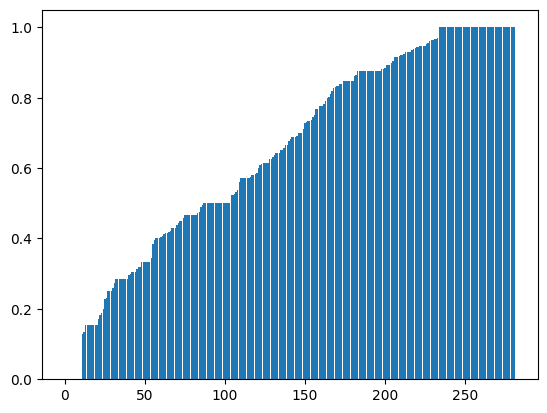

In [7]:
import pandas as pd 
from matplotlib import pyplot as plt 


# 列表的柱状图：
data = relevance_score

sorted_data = sorted(data)

plt.bar(range(len(sorted_data)), sorted_data)
plt.show()



 



In [17]:
import json 

all_data = []
with open('notebooklm_examples_new_contextual_relevance.jsonl', 'r') as f:
    for line in f.readlines():
        data = json.loads(line)
        all_data.append(data)


all_data = all_data[:-2]

print(len(all_data))
print(all_data[0]['chunks'][0].keys())




19
dict_keys(['content', 'reference', 'contextual_relevance'])


In [18]:
all_score = []

print(len(all_data))
print(all_data[0]['chunks'][0].keys())

for data in all_data:
    for chunk in data['chunks']:
        all_score.append(chunk['contextual_relevance']['score'])

print(all_score)






19
dict_keys(['content', 'reference', 'contextual_relevance'])
[1.0, 0.6666666666666666, 1.0, 1.0, 1.0, 0.5454545454545454, 1.0, 1.0, 1.0, 0.0, 0.7, 0.7, 0.16666666666666666, 1.0, 1.0, 1.0, 0.8, 1.0, 0.4444444444444444, 0.25, 0.7142857142857143, 0.7142857142857143, 0.23076923076923078, 0.29411764705882354, 0.23529411764705882, 0.6666666666666666, 0.4444444444444444, 0.16666666666666666, 0.4, 0.7058823529411765, 0.875, 0.6666666666666666, 0.75, 0.3181818181818182, 0.3333333333333333, 0.5333333333333333, 0.6363636363636364, 0.4444444444444444, 0.0, 0.4, 0.5, 0.375, 1.0, 0.2857142857142857, 0.6666666666666666, 0.6666666666666666, 0.3333333333333333, 0.2, 0.7777777777777778, 1.0, 0.8571428571428571, 1.0, 1.0, 0.7142857142857143, 1.0, 1.0, 1.0, 0.7142857142857143, 1.0, 0.5, 0.6923076923076923, 0.8888888888888888, 0.5, 0.5, 0.5, 0.8888888888888888, 0.9230769230769231, 0.9411764705882353, 0.8, 0.7, 0.5, 0.7692307692307693, 1.0, 1.0, 0.8823529411764706, 0.9090909090909091, 0.7272727272727273, 

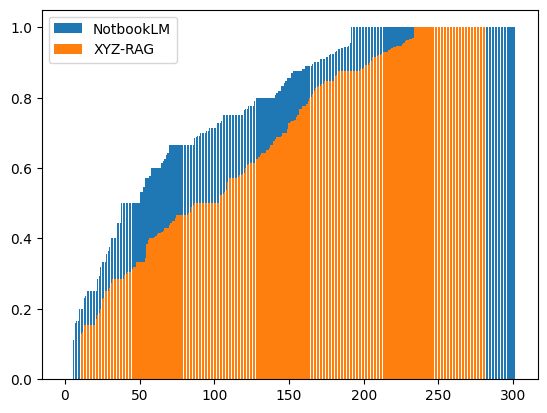

In [19]:
import pandas as pd 
from matplotlib import pyplot as plt 


# 列表的柱状图：

all_score = sorted(all_score)
relevance_score = sorted(relevance_score)

plt.bar(range(len(all_score)), all_score, label='NotbookLM')
plt.bar(range(len(relevance_score)), relevance_score, label='XYZ-RAG')
plt.legend()
plt.show()